# Scalability Experiments
Columns experiment (varying number of attributes) and Memory experiment
(varying JVM heap sizes).

In [1]:
from chart_utils import *
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

## Columns Experiment

dataset_name='flights_20_500k' num_cols=20 float(last_row['timeElapsedMs']) / 1000.0=3014.235
dataset_name='flights_20_500k' num_cols=20 float(last_row['timeElapsedMs']) / 1000.0=2995.278
dataset_name='plista_1k' num_cols=63 float(last_row['timeElapsedMs']) / 1000.0=7014.577
dataset_name='plista_1k' num_cols=63 float(last_row['timeElapsedMs']) / 1000.0=6991.621


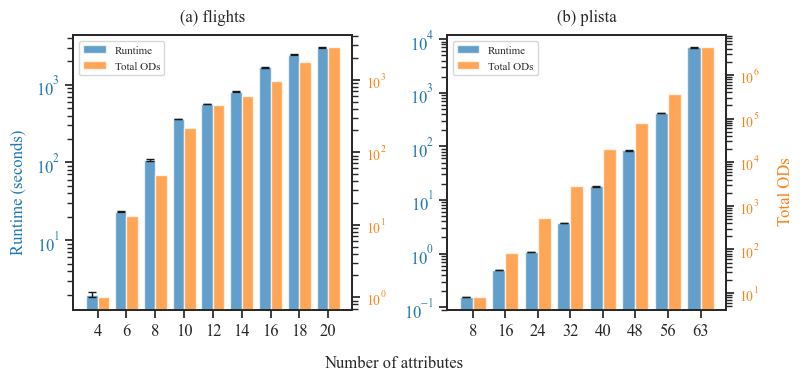

In [2]:
def parse_columns_experiment():
    """Parse all columns experiment intermediate data."""
    columns_dir = benchmark_data_path / "dynsbod_results/columns"
    intermediate_dir = benchmark_data_path / "dynsbod_results/intermediate"
    results = defaultdict(list)

    full_columns = {'flights': 20, 'plista': 63}

    for file in columns_dir.glob("*_stdout.intermediate.csv"):
        match = re.search(r'algo\d+_java\d+_(.+?)_ncols_(\d+)_run\d+', file.name)
        if not match:
            continue

        dataset_name = match.group(1)
        num_cols = int(match.group(2))

        try:
            df = load_intermediate_runs(file, filter_last_increment=True)
            if len(df) > 0:
                last_row = df.iloc[-1]
                results[(dataset_name, num_cols)].append({
                    'runtime': float(last_row['timeElapsedMs']) / 1000.0,
                    'total_ods': int(last_row['totalODs']),
                })
        except Exception as e:
            print(f"Error parsing {file}: {e}")

    # Add full column data from intermediate experiment
    for file in intermediate_dir.glob("*_stdout.intermediate.csv"):
        match = re.search(r'algo\d+_java\d+_(.+?)_run\d+', file.name)
        if not match:
            continue

        dataset_name = match.group(1)
        matched_dataset = next((ds for ds in full_columns if ds in dataset_name.lower()), None)

        if not matched_dataset:
            continue

        num_cols = full_columns[matched_dataset]

        try:
            if '_half_' in str(file): continue 
            if '-reduced' in str(file): continue
            df = load_intermediate_runs(file, filter_last_increment=True)
            if len(df) > 0:
                last_row = df.iloc[-1]
                print(f"{dataset_name=} {num_cols=} {float(last_row['timeElapsedMs']) / 1000.0=}")
                results[(matched_dataset, num_cols)].append({
                    'runtime': float(last_row['timeElapsedMs']) / 1000.0,
                    'total_ods': int(last_row['totalODs']),
                })
        except Exception as e:
            print(f"Error parsing {file}: {e}")

    return results


def plot_columns_experiment(results):
    """Create bar charts for columns experiment."""
    import numpy as np

    datasets = defaultdict(lambda: {'num_cols': [], 'runtime': [], 'runtime_err': [],
                                    'total_ods': [], 'total_ods_err': []})

    for (dataset, num_cols), runs in results.items():
        runtimes = [r['runtime'] for r in runs]
        ods = [r['total_ods'] for r in runs]
        datasets[dataset]['num_cols'].append(num_cols)
        datasets[dataset]['runtime'].append(np.mean(runtimes))
        datasets[dataset]['runtime_err'].append(np.std(runtimes) if len(runtimes) > 1 else 0)
        datasets[dataset]['total_ods'].append(np.mean(ods))
        datasets[dataset]['total_ods_err'].append(np.std(ods) if len(ods) > 1 else 0)

    for dataset in datasets:
        indices = sorted(
            range(len(datasets[dataset]['num_cols'])),
            key=lambda i: datasets[dataset]['num_cols'][i],
        )
        for key in ['num_cols', 'runtime', 'runtime_err', 'total_ods', 'total_ods_err']:
            datasets[dataset][key] = [datasets[dataset][key][i] for i in indices]

    num_datasets = len(datasets)
    fig, axes = plt.subplots(1, num_datasets, figsize=(8, 4))
    if num_datasets == 1:
        axes = [axes]

    for idx, (dataset_name, data) in enumerate(sorted(datasets.items())):
        ax1 = axes[idx]
        ax2 = ax1.twinx()
        x_pos = range(len(data['num_cols']))

        ax1.bar([x - 0.2 for x in x_pos], data['runtime'], width=0.4,
                color='tab:blue', alpha=0.7, label='Runtime',
                yerr=data['runtime_err'], capsize=3, error_kw={'elinewidth': 1})
        ax1.set_xlabel('')
        ax1.set_ylabel('')
        ax1.tick_params(axis='y', labelcolor='tab:blue', labelsize=12)
        ax1.tick_params(axis='x', labelsize=12)
        ax1.set_xticks(x_pos)
        ax1.set_xticklabels(data['num_cols'])
        ax1.set_yscale("log")

        ax2.bar([x + 0.2 for x in x_pos], data['total_ods'], width=0.4,
                color='tab:orange', alpha=0.7, label='Total ODs')
        ax2.set_ylabel('')
        ax2.tick_params(axis='y', labelcolor='tab:orange', labelsize=10)
        ax2.set_yscale("log")
        ax1.set_title(format_dataset_name(dataset_name, index=idx), fontsize=12, pad=10)

        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=8)

    fig.supxlabel('Number of attributes', fontsize=12, y=0.05)
    fig.text(0.02, 0.5, 'Runtime (seconds)', va='center', rotation='vertical',
             fontsize=12, color='tab:blue')
    fig.text(0.98, 0.5, 'Total ODs', va='center', rotation='vertical',
             fontsize=12, color='tab:orange')

    plt.tight_layout(rect=[0.03, 0.00, 0.98, 1])
    save_figure("columns_experiment")
    plt.show()


columns_results = parse_columns_experiment()
plot_columns_experiment(columns_results)


## Memory Experiment

/var/folders/6w/1dx0z2b91j798m812cq_1d8m0000gn/T/ipykernel_2167/3200007378.py:139: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.06, 1, 1])


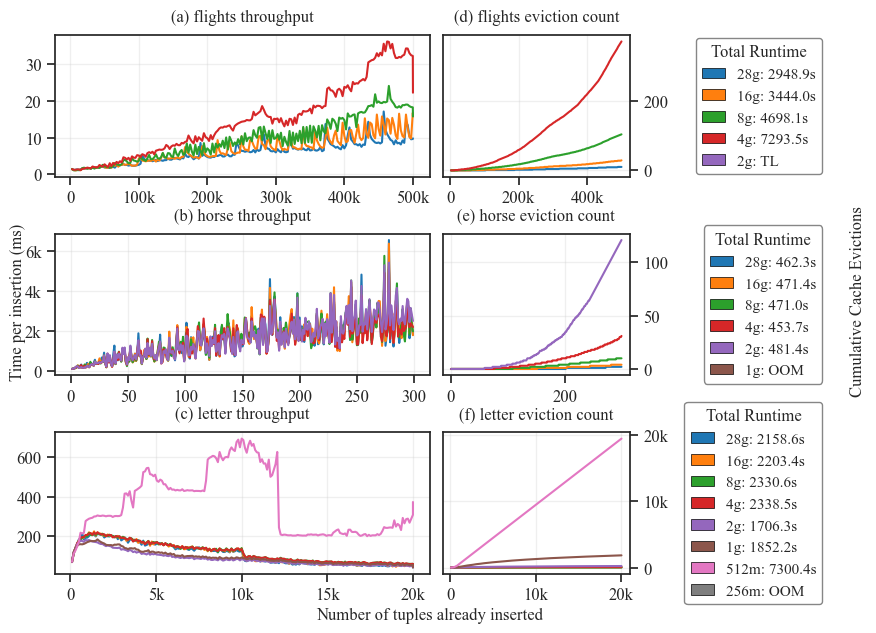

In [3]:
def get_memory_config_label(java_idx):
    """Map java index to memory configuration label."""
    configs = [
        "28g", "16g", "8g", "4g",
        "2g", "1g", "512m", "256m",
        "Xms28g -Xmx28g", "Xms256m -Xmx28g",
    ]
    return configs[java_idx]


def parse_memory_experiment():
    """Parse all memory experiment intermediate data."""
    memory_dir = benchmark_data_path / "dynsbod_results/memory"
    results = defaultdict(lambda: defaultdict(list))

    for file in memory_dir.glob("*_stdout.intermediate.csv"):
        match = re.search(r'algo\d+_java(\d+)_(.+?)_run1', file.name)
        if not match:
            continue

        java_idx = int(match.group(1))
        dataset_name = match.group(2)

        try:
            df = load_intermediate_runs(file, filter_last_increment=True)
            if len(df) > 0:
                last_row = df.iloc[-1]
                results[dataset_name][java_idx].append({
                    'df': df,
                    'runtime': float(last_row['timeElapsedMs']) / 1000.0,
                    'cache_evictions': int(last_row['numCacheEvictions']),
                })
        except Exception as e:
            print(f"Error parsing {file}: {e}")

    return results


def plot_memory_experiment_combined(results, datasets_to_plot=None):
    """Create a single figure with subplots for multiple datasets showing memory configurations."""
    if datasets_to_plot is None:
        datasets_to_plot = ['flights_20_500k', 'horse', 'letter']

    colors = plt.cm.tab10(range(10))
    available_datasets = [ds for ds in datasets_to_plot if ds in results]
    if not available_datasets:
        print("No data found for any of the requested datasets")
        return

    n_datasets = len(available_datasets)
    fig = plt.figure(figsize=(10, 7))
    gs = GridSpec(n_datasets, 3, figure=fig, width_ratios=[4, 2, 2],
                  hspace=0.4, wspace=0.05)

    for plot_idx, dataset_name in enumerate(available_datasets):
        ax_time = fig.add_subplot(gs[plot_idx, 0])
        ax_evictions = fig.add_subplot(gs[plot_idx, 1])
        ax_runtime = fig.add_subplot(gs[plot_idx, 2])

        memory_configs = [i for i in sorted(results[dataset_name].keys()) if i not in range(8, 10)]
        runtime_data = []

        for java_idx in memory_configs:
            config_label = get_memory_config_label(java_idx)
            df = results[dataset_name][java_idx][0]['df']
            runtime = results[dataset_name][java_idx][0]['runtime']
            color = colors[java_idx % 10]

            runtime_data.append((config_label, runtime, color))

            ax_time.plot(df['lastOperationId'], df['timePerOperation'],
                        label=config_label, color=color, linewidth=1.5)
            ax_evictions.plot(df['lastOperationId'], df['numCacheEvictions'],
                            label=config_label, color=color, linewidth=1.5)

        ax_runtime.axis('off')

        legend_elements = [
            mpatches.Patch(
                facecolor=color, edgecolor='black', linewidth=0.5,
                label=f'{label}: {runtime:.1f}s'
            )
            for label, runtime, color in runtime_data
        ]
        # OOM / TL annotations as seen in stdout files
        if dataset_name == 'horse':
            legend_elements.append(mpatches.Patch(
                facecolor=colors[len(legend_elements)], edgecolor='black',
                linewidth=0.5, label='1g: OOM'
            ))
        elif dataset_name == 'letter':
            legend_elements.append(mpatches.Patch(
                facecolor=colors[len(legend_elements)], edgecolor='black',
                linewidth=0.5, label='256m: OOM'
            ))
        elif 'flights' in dataset_name:
            legend_elements.append(mpatches.Patch(
                facecolor=colors[len(legend_elements)], edgecolor='black',
                linewidth=0.5, label='2g: TL'
            ))

        legend = ax_runtime.legend(
            handles=legend_elements, loc='center right',
            fontsize=11, frameon=True,
            title='Total Runtime', title_fontsize=12,
            ncol=1, columnspacing=0.5, handlelength=1.5,
            framealpha=0.95, edgecolor='gray'
        )
        legend.get_frame().set_linewidth(1.0)

        ax_time.set_xlabel('')
        ax_time.set_ylabel('')
        ax_evictions.set_xlabel('')
        ax_evictions.set_ylabel('')

        ax_time.set_title(
            format_dataset_name(dataset_name, index=plot_idx) + " throughput",
            fontsize=12, pad=10
        )
        ax_evictions.set_title(
            format_dataset_name(dataset_name, index=plot_idx + n_datasets) + " eviction count",
            fontsize=12, pad=10
        )

        ax_time.tick_params(axis='both', labelsize=12)
        ax_evictions.tick_params(axis='both', labelsize=12)
        ax_time.xaxis.set_major_formatter(FuncFormatter(human_format))
        ax_time.yaxis.set_major_formatter(FuncFormatter(human_format))
        ax_evictions.xaxis.set_major_formatter(FuncFormatter(human_format))
        ax_evictions.yaxis.tick_right()
        ax_evictions.yaxis.set_major_formatter(FuncFormatter(human_format))
        ax_time.grid(True, alpha=0.3)
        ax_evictions.grid(True, alpha=0.3)

    fig.supxlabel('Number of tuples already inserted', fontsize=12, y=0.04)
    fig.text(0.08, 0.5, 'Time per insertion (ms)', va='center', rotation='vertical', fontsize=12)
    fig.text(0.92, 0.5, 'Cumulative Cache Evictions', va='center', rotation='vertical', fontsize=12)

    plt.tight_layout(rect=[0, 0.06, 1, 1])
    save_figure("memory_experiment")
    plt.show()


memory_results = parse_memory_experiment()
plot_memory_experiment_combined(memory_results, datasets_to_plot=['flights_20_500k', 'horse', 'letter'])